# YÜZ TESPİTİ (FACE DETECTION) - HAAR CASCADE ALGORİTMASI

## ALGORİTMA AÇIKLAMASI

Bu notebook, Viola-Jones algoritmasına dayalı **Haar Cascade** sınıflandırıcısı kullanarak görüntülerde yüz tespiti yapar.

### Adım 1: Görüntü Gri Tonlamaya Çevrilir
- Renkli görüntü (BGR), gri tonlamaya (grayscale) dönüştürülür.
- Haar özellikleri renk bilgisine ihtiyaç duymaz, yoğunluk farklarına bakar.

### Adım 2: Haar Benzeri Özellikler (Haar-like Features)
- Beyaz ve siyah dikdörtgen bölgelerin piksel yoğunlukları toplamı arasındaki fark hesaplanır.
- Kenar, çizgi ve dörtgen özellikleri kullanılır.
- Örneğin: Göz bölgesi (koyu), yanak bölgesine (açık) göre daha koyudur.

### Adım 3: Integral Image (Bütünsel Görüntü)
- Herhangi bir dikdörtgen bölgenin piksel toplamını O(1) sürede hesaplamak için integral görüntü kullanılır.
- Bu, algoritmayı çok hızlı hale getirir.

### Adım 4: AdaBoost ile Özellik Seçimi
- Binlerce Haar özelliği arasından en iyileri seçilir.
- Zayıf sınıflandırıcılar güçlü bir sınıflandırıcıda birleştirilir.

### Adım 5: Cascade (Basamaklı) Sınıflandırma
- Sınıflandırıcılar ardışık aşamalardan oluşur.
- Her aşama bir dizi özellik içerir.
- Bir bölge herhangi bir aşamada "yüz değil" derse hemen elenir.
- Yüz olmayan bölgeler hızlıca elenir, sadece yüz adayları detaylı incelenir.

### Adım 6: Çoklu Ölçekte Tarama (Multi-scale Detection)
- Görüntü farklı boyutlarda ölçeklenir ve her ölçekte pencere kaydırılarak taranır.
- `detectMultiScale()` parametreleri:
  - **scaleFactor**: Her ölçekte görüntü ne kadar küçültülecek (1.1 = %10)
  - **minNeighbors**: Bir yüzün kaç komşu pencere tarafından doğrulanması gerektiği
  - **minSize**: Tespit edilecek en küçük yüz boyutu

In [7]:
import cv2
import os
import glob
import matplotlib.pyplot as plt

# Haar Cascade sınıflandırıcı dosyasının yolu
CASCADE_PATH = os.path.join("opencv", "opencv", "haarcascade_frontalface_default.xml")
TEST_IMG_DIR = os.path.join("test", "test")
OUTPUT_DIR = "detected_faces"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Haar Cascade sınıflandırıcısını yükle
face_cascade = cv2.CascadeClassifier(CASCADE_PATH)
if face_cascade.empty():
    raise FileNotFoundError(f"Haar cascade dosyası bulunamadı: {CASCADE_PATH}")

print("✅ Haar Cascade sınıflandırıcısı yüklendi.")
print(f"📁 Test görüntüleri: {TEST_IMG_DIR}/")

✅ Haar Cascade sınıflandırıcısı yüklendi.
📁 Test görüntüleri: test/test/


In [8]:
# Test görüntülerini listele
image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.webp"]
image_paths = []
for ext in image_extensions:
    image_paths.extend(glob.glob(os.path.join(TEST_IMG_DIR, ext)))

print(f"Toplam {len(image_paths)} görüntü bulundu:")
for i, p in enumerate(image_paths, 1):
    print(f"  {i:2d}. {os.path.basename(p)}")

Toplam 9 görüntü bulundu:
   1. Sharapova-profile-1280x720.jpg
   2. tst.jpg
   3. cf7b436c6ff49688502acad26cea2619.jpg
   4. 1807074.jpg
   5. 84c93a095f6ebabdbfa557e468f5952e.jpg
   6. kohli1.jpg
   7. 960.jpg
   8. xdeepika-padukone_13.jpg.pagespeed.ic.LsGoQgECFh.jpg
   9. 72168734.webp


In [9]:
# Tüm görüntülerde yüz tespiti yap
results = []

for img_path in image_paths:
    img = cv2.imread(img_path)
    if img is None:
        print(f"  [!] Okunamadı: {img_path}")
        continue

    # Adım 1: Gri tonlamaya çevir
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Adım 5-6: Cascade ile çoklu ölçekte yüz tespiti
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30),
        flags=cv2.CASCADE_SCALE_IMAGE
    )

    # Tespit edilen yüzlerin etrafına dikdörtgen çiz
    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(img, "Yuz", (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # Sonucu kaydet
    base_name = os.path.basename(img_path)
    output_path = os.path.join(OUTPUT_DIR, f"detected_{base_name}")
    cv2.imwrite(output_path, img)

    results.append((base_name, len(faces), output_path, img))

    dosya_adi = os.path.basename(img_path)
    print(f"  [OK] {dosya_adi:45s} -> {len(faces)} yüz tespit edildi")

print(f" ✅ Tüm sonuçlar '{OUTPUT_DIR}/' klasörüne kaydedildi.")

  [OK] Sharapova-profile-1280x720.jpg                -> 1 yüz tespit edildi
  [OK] tst.jpg                                       -> 1 yüz tespit edildi
  [OK] cf7b436c6ff49688502acad26cea2619.jpg          -> 1 yüz tespit edildi
  [OK] 1807074.jpg                                   -> 2 yüz tespit edildi
  [OK] 84c93a095f6ebabdbfa557e468f5952e.jpg          -> 1 yüz tespit edildi
  [OK] kohli1.jpg                                    -> 1 yüz tespit edildi
  [OK] 960.jpg                                       -> 1 yüz tespit edildi
  [OK] xdeepika-padukone_13.jpg.pagespeed.ic.LsGoQgECFh.jpg -> 1 yüz tespit edildi
  [OK] 72168734.webp                                 -> 1 yüz tespit edildi
 ✅ Tüm sonuçlar 'detected_faces/' klasörüne kaydedildi.


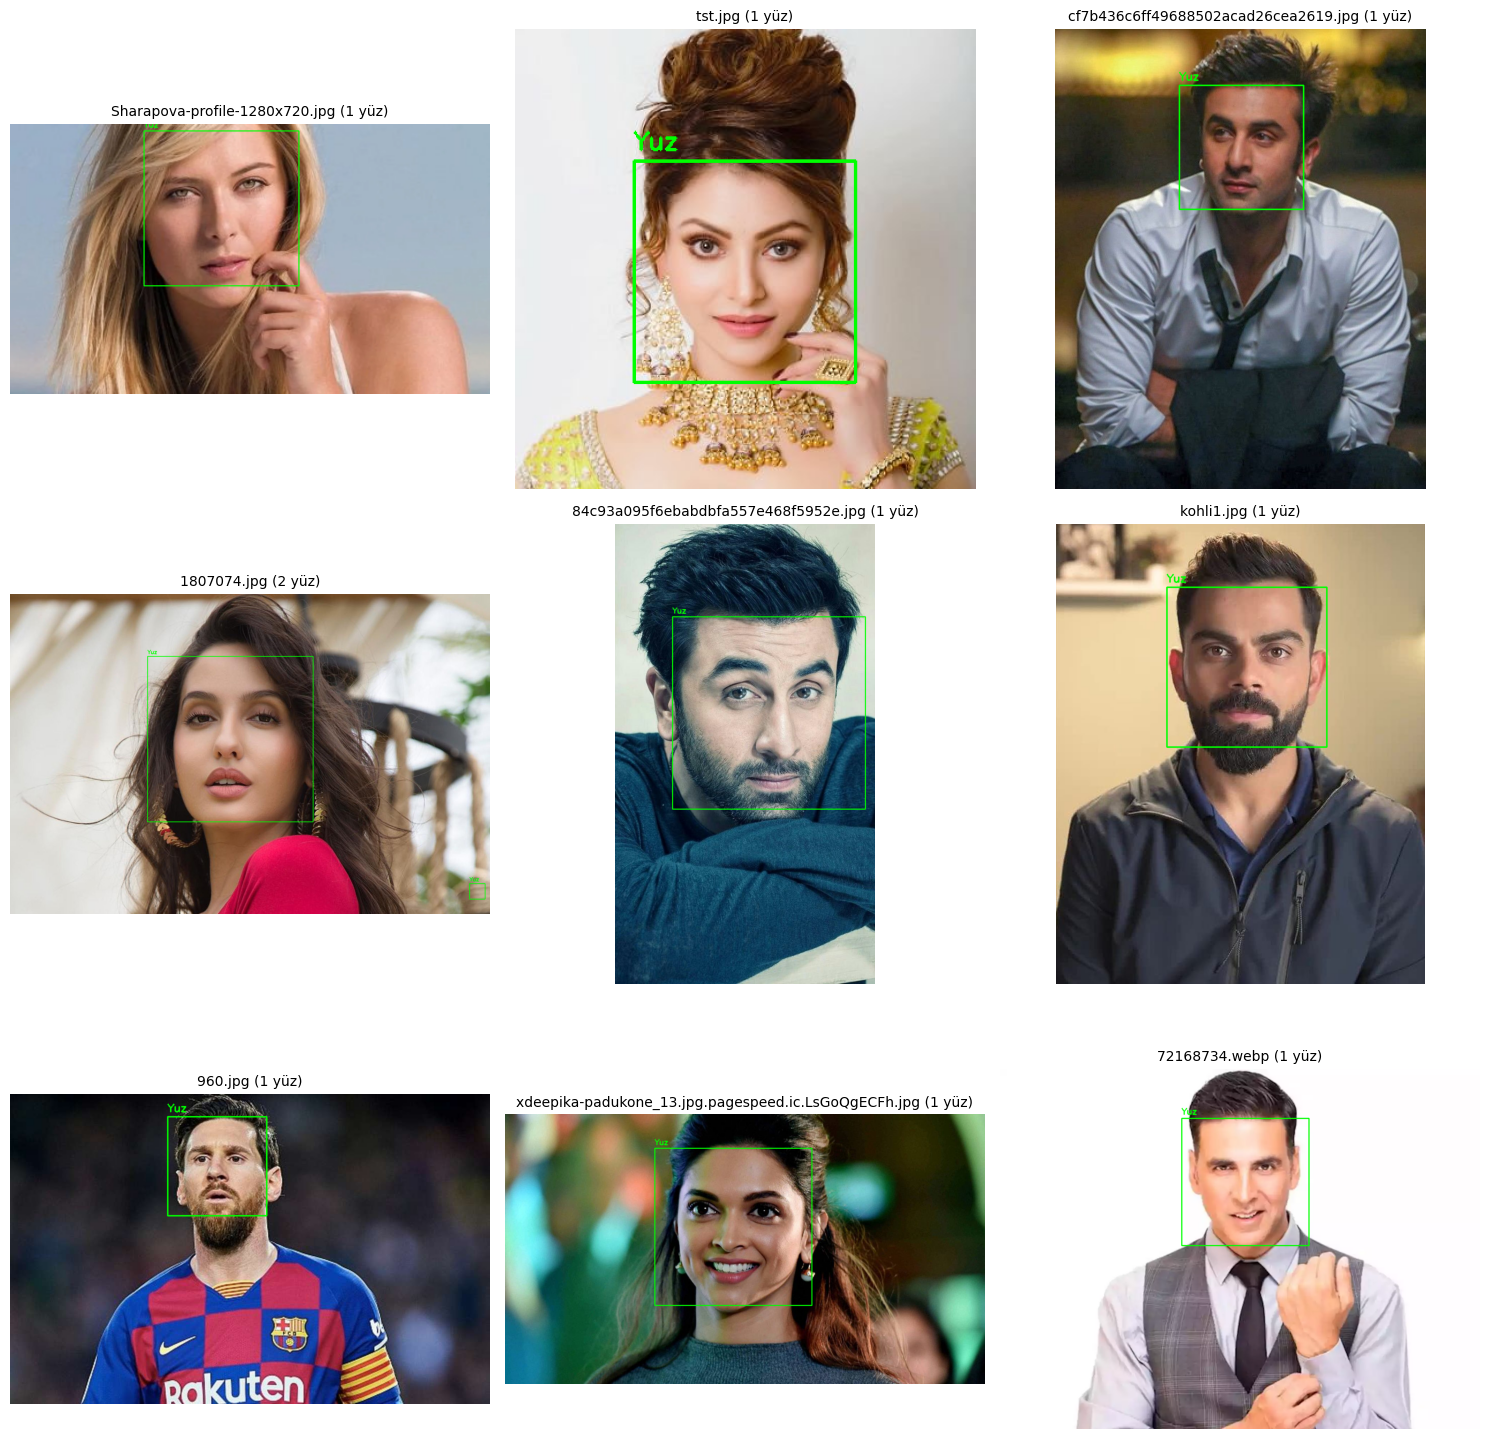

📊 Kolaj 'detected_faces/collage_results.png' olarak kaydedildi.


In [11]:
# Sonuçları görselleştir
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.ravel()

for i, (name, count, path, img) in enumerate(results):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{name} ({count} yüz)", fontsize=10)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "collage_results.png"), dpi=150)
plt.show()

print(f"📊 Kolaj '{OUTPUT_DIR}/collage_results.png' olarak kaydedildi.")